# 02 · 보드 위 물체 크기 측정 (W × L × H)

ChArUco 보드 위에 물체를 올리고 **한 장** 찍은 사진에서 물체의 **바닥 치수(가로·세로)·중심·높이**를 추정한다.

**전제:** `01_charuco_calibration.ipynb`로 `output/camera_intrinsics.npz`가 이미 만들어져 있어야 한다 (K·왜곡계수). 캘리브레이션 덕분에 FOV/왜곡 오차가 제거되어 정밀 측정이 가능하다.

**원리:**
- 보드 검출 → 카메라 기준 **보드 평면 포즈**.
- 물체 **바닥 코너 픽셀**을 보드 평면(z=0)으로 역투영 → 실제 mm 좌표 → 가로·세로·면적·중심.
- 물체 **수직 모서리**(바닥점, 꼭대기점)로 높이 계산.

**한 시점의 한계(솔직):** 뒷면은 가려지므로 완전한 3D는 못 잰다. 박스형 물체의 바운딩 박스(W×L×H)에 가장 정확하고, 불규칙 물체는 보이는 실루엣 기준 근사다.

In [1]:
import os, sys, glob, json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(ROOT, 'src'))
import aruco_utils as au
print('OpenCV', cv2.__version__)

SCENE_DIR = os.path.join(ROOT, 'data', 'scene_images')
OUTPUT_DIR = os.path.join(ROOT, 'output')
os.makedirs(SCENE_DIR, exist_ok=True)

# ===== 설정 =====
SCENE_IMAGE = None       # None이면 scene_images/ 첫 이미지 자동 선택
# 보드 규격 (01 노트북과 동일해야 함)
SQUARES_X, SQUARES_Y = 5, 7
SQUARE_LENGTH_M = 0.038
MARKER_LENGTH_M = 0.038 * 22 / 30
ARUCO_DICT = cv2.aruco.DICT_5X5_1000

OpenCV 4.13.0


In [3]:
# 캘리브레이션 로드 (필수)
intr_path = os.path.join(OUTPUT_DIR, 'camera_intrinsics.npz')
assert os.path.exists(intr_path), '먼저 01_charuco_calibration.ipynb 로 캘리브레이션을 완료하세요.'
K, dist = au.load_intrinsics(intr_path)
print('K =\n', K)
print('dist =', dist.ravel())

# 씬 이미지 로드
if SCENE_IMAGE is None:
    files = []
    for e in ('*.jpg','*.jpeg','*.png','*.bmp','*.JPG','*.JPEG','*.PNG'):
        files.extend(glob.glob(os.path.join(SCENE_DIR, e)))
    files = sorted(set(files))
    assert files, f'scene_images/ 에 (보드+물체) 사진을 넣으세요: {SCENE_DIR}'
    scene_path = files[0]
else:
    scene_path = os.path.join(SCENE_DIR, SCENE_IMAGE)
img = cv2.imread(scene_path)
assert img is not None, '이미지 로드 실패'
print('사용 이미지:', scene_path, img.shape[1], 'x', img.shape[0])

K =
 [[1.42870114e+03 0.00000000e+00 8.97987651e+02]
 [0.00000000e+00 1.45112605e+03 5.76865072e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
dist = [-3.59477496e-01  8.88905243e-02 -1.21840285e-02  1.48078717e-04
  3.54635490e-02]
사용 이미지: d:\vision algorithm\data\scene_images\WIN_20260705_00_38_09_Pro.jpg 1920 x 1080


보드 검출 OK (charuco 코너 19개)
보드까지 거리 ~ 27.302093176709242 cm


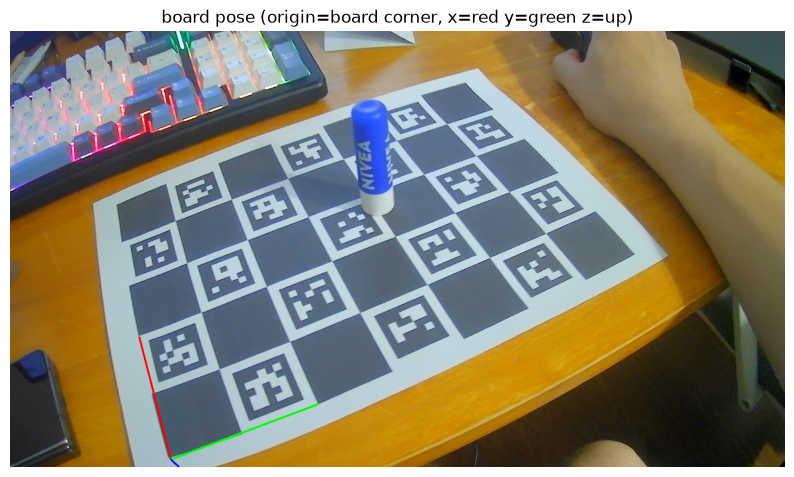

In [4]:
# 보드 포즈 검출
dictionary = cv2.aruco.getPredefinedDictionary(ARUCO_DICT)
board = cv2.aruco.CharucoBoard((SQUARES_X, SQUARES_Y), SQUARE_LENGTH_M, MARKER_LENGTH_M, dictionary)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
rvec, tvec, ch_corners, ch_ids = au.detect_charuco_pose(gray, board, K, dist)
assert rvec is not None, '보드가 검출되지 않았습니다. 보드가 충분히 보이는지/초점 확인.'
print(f'보드 검출 OK (charuco 코너 {len(ch_corners)}개)')
print('보드까지 거리 ~', np.linalg.norm(tvec)*100, 'cm')

vis = img.copy()
cv2.drawFrameAxes(vis, K, dist, rvec, tvec, SQUARE_LENGTH_M * 2, 3)
plt.figure(figsize=(10, 7)); plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title('board pose (origin=board corner, x=red y=green z=up)'); plt.axis('off'); plt.show()

## 물체 분할 (반자동) — 후보점 찾기

기본은 **채도(saturation) 기반** 분할: 보드는 흑백(무채색)이라 채도가 낮고, 색이 있는 물체는 채도가 높아 잘 분리된다. 물체가 회색/흰색이면 `SEG_MODE`를 바꾸거나 아래 수동 좌표 입력을 쓰면 된다.

여기서 나온 **바닥 후보점·꼭대기 후보점**을 다음 셀에서 확인하고, 틀리면 픽셀 좌표를 직접 지정한다.

자동 제안 → 바닥 후보 base_px = [514, 1079] , 꼭대기 후보 top_px = [1001, 0]


d:\python\envs\vision_aruco\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45576 (\N{HANGUL SYLLABLE NUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python\envs\vision_aruco\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python\envs\vision_aruco\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51004 (\N{HANGUL SYLLABLE EU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python\envs\vision_aruco\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python\envs\vision_aruco\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54589 (\N{HANGUL SYLLABLE PIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print

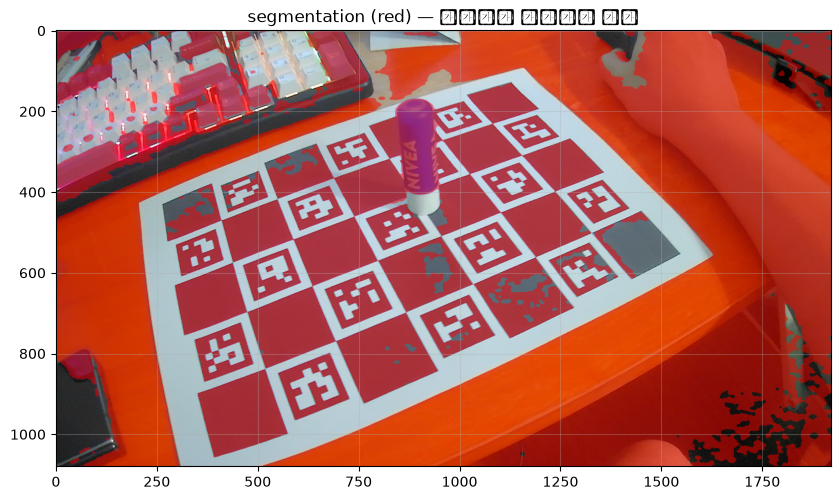

In [5]:
SEG_MODE = 'saturation'   # 'saturation' | 'none'(수동 좌표만)
SAT_THRESH = 60           # 채도 임계값 (물체가 흐리게 잡히면 낮추고, 보드가 섞이면 높임)

mask = np.zeros(gray.shape, np.uint8)
if SEG_MODE == 'saturation':
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = (hsv[:, :, 1] > SAT_THRESH).astype(np.uint8) * 255
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)

cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
sugg_base = sugg_top = None
if cnts:
    c = max(cnts, key=cv2.contourArea).reshape(-1, 2)
    sugg_base = c[np.argmax(c[:, 1])]   # 가장 아래(=바닥 접점 후보)
    sugg_top = c[np.argmin(c[:, 1])]    # 가장 위(=꼭대기 후보)
    print('자동 제안 → 바닥 후보 base_px =', sugg_base.tolist(), ', 꼭대기 후보 top_px =', sugg_top.tolist())
else:
    print('분할 마스크에서 윤곽을 못 찾음 → 아래 수동 좌표를 사용하세요.')

ov = img.copy(); ov[mask > 0] = (0.5 * ov[mask > 0] + np.array([0, 0, 127])).astype(np.uint8)
plt.figure(figsize=(10, 7)); plt.imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB))
plt.title('segmentation (red) — 눈금으로 픽셀좌표 읽기'); plt.grid(True, alpha=0.3); plt.show()

## 측정 입력 지정

- **`FOOTPRINT_PX`**: 물체의 **바닥 코너들** 픽셀 좌표 (보드에 닿는 지점). 박스면 보이는 바닥 코너 3~4개. 위 그림 눈금으로 읽어 입력.
- **`VERTICAL_EDGE_PX`**: 물체의 한 **수직 모서리** = (바닥 픽셀, 꼭대기 픽셀). 자동 제안값을 기본으로 두되 부정확하면 수정.

> 정확도 팁: 코너 픽셀을 정밀하게 찍을수록(확대해서) 오차가 준다. 물체를 화면 중앙 근처에 두고 찍으면 좋다.

In [6]:
# === 여기에 픽셀 좌표 입력 (예시값 — 실제 사진에 맞게 수정) ===
FOOTPRINT_PX = None   # 예: [[810,720],[980,700],[1010,830],[840,860]]  (바닥 코너들)
VERTICAL_EDGE_PX = None  # 예: [[810,720],[815,560]]  ([바닥, 꼭대기])

# 미지정 시 자동 제안으로 채움(대략치 — 확인 필요)
if VERTICAL_EDGE_PX is None and sugg_base is not None:
    VERTICAL_EDGE_PX = [sugg_base.tolist(), sugg_top.tolist()]
    print('VERTICAL_EDGE_PX 자동설정:', VERTICAL_EDGE_PX)
if FOOTPRINT_PX is None and cnts:
    # 임시: 마스크 윤곽 전체를 바닥으로 간주(낮은 물체에만 유효). 높은 물체는 수동 지정 권장.
    FOOTPRINT_PX = c.tolist()
    print(f'FOOTPRINT_PX 자동설정: 윤곽점 {len(FOOTPRINT_PX)}개 (낮은 물체 가정 — 높은 물체는 수동 코너 입력 권장)')

VERTICAL_EDGE_PX 자동설정: [[514, 1079], [1001, 0]]
FOOTPRINT_PX 자동설정: 윤곽점 3312개 (낮은 물체 가정 — 높은 물체는 수동 코너 입력 권장)


In [7]:
# 측정 계산
assert FOOTPRINT_PX, 'FOOTPRINT_PX 를 지정하세요.'
base_pts = au.pixels_to_plane(FOOTPRINT_PX, K, dist, rvec, tvec)[:, :2]  # 보드평면 mm(=m) 좌표

rect = cv2.minAreaRect(base_pts.astype(np.float32))  # ((cx,cy),(w,l),angle)
(cx, cy), (rw, rl), ang = rect
area = rw * rl
print('=== 바닥(footprint) ===')
print(f'  가로 W = {rw*1000:.1f} mm')
print(f'  세로 L = {rl*1000:.1f} mm')
print(f'  면적    = {area*1e4:.1f} cm^2')
print(f'  중심(보드좌표) = ({cx*1000:.1f}, {cy*1000:.1f}) mm')

height = None
if VERTICAL_EDGE_PX:
    height, P0 = au.height_from_vertical_edge(VERTICAL_EDGE_PX[0], VERTICAL_EDGE_PX[1], K, dist, rvec, tvec)
    print('=== 높이 ===')
    print(f'  H = {height*1000:.1f} mm  (바닥접점 {P0[:2].round(3)})')
print('\n=> 바운딩박스 (W x L x H) = '
      f'{rw*1000:.1f} x {rl*1000:.1f} x {(height*1000 if height else float("nan")):.1f} mm')

=== 바닥(footprint) ===
  가로 W = 459.4 mm
  세로 L = 441.6 mm
  면적    = 2028.6 cm^2
  중심(보드좌표) = (64.0, 330.7) mm
=== 높이 ===
  H = 192.0 mm  (바닥접점 [-0.012  0.021])

=> 바운딩박스 (W x L x H) = 459.4 x 441.6 x 192.0 mm


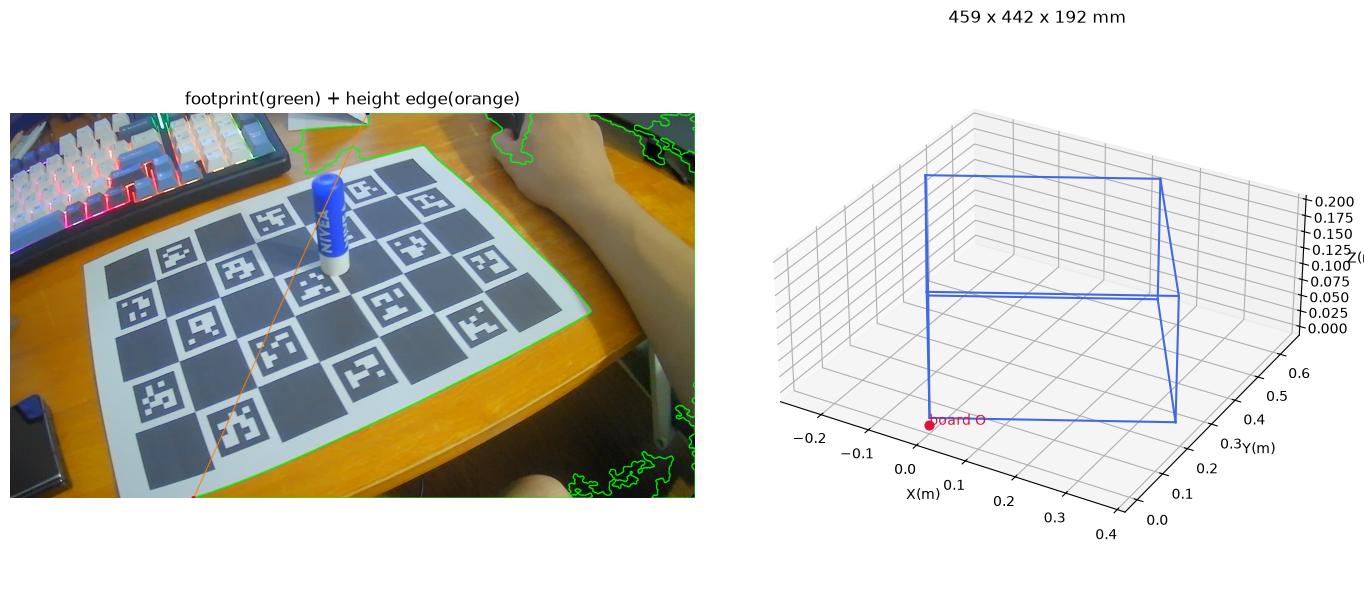

In [8]:
# 시각화: 2D 오버레이 + 3D 바운딩 박스(보드 좌표계)
fig = plt.figure(figsize=(14, 6))

# (a) 2D
ax1 = fig.add_subplot(1, 2, 1)
ov2 = img.copy()
fp = np.array(FOOTPRINT_PX, np.int32)
cv2.polylines(ov2, [fp], True, (0, 255, 0), 2)
if VERTICAL_EDGE_PX:
    b, t = np.array(VERTICAL_EDGE_PX[0], int), np.array(VERTICAL_EDGE_PX[1], int)
    cv2.line(ov2, tuple(b), tuple(t), (0, 128, 255), 2)
    cv2.circle(ov2, tuple(b), 6, (0, 0, 255), -1); cv2.circle(ov2, tuple(t), 6, (255, 0, 0), -1)
ax1.imshow(cv2.cvtColor(ov2, cv2.COLOR_BGR2RGB)); ax1.axis('off')
ax1.set_title('footprint(green) + height edge(orange)')

# (b) 3D box in board frame
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
box = cv2.boxPoints(rect)  # 4 base corners (mm/m)
H = height if height else 0.0
base3 = np.c_[box, np.zeros(4)]
top3 = np.c_[box, np.full(4, H)]
for a, bb in [(base3[i], base3[(i+1) % 4]) for i in range(4)] + \
             [(top3[i], top3[(i+1) % 4]) for i in range(4)] + \
             [(base3[i], top3[i]) for i in range(4)]:
    ax2.plot(*zip(a, bb), c='royalblue')
# 보드 원점 축
ax2.scatter(0, 0, 0, c='crimson', s=40); ax2.text(0, 0, 0, 'board O', color='crimson')
ax2.set_xlabel('X(m)'); ax2.set_ylabel('Y(m)'); ax2.set_zlabel('Z(m)')
ax2.set_title(f'{rw*1000:.0f} x {rl*1000:.0f} x {H*1000:.0f} mm')
try:
    ax2.set_box_aspect((rw, rl, max(H, 1e-3)))
except Exception:
    pass
plt.tight_layout(); plt.show()

In [9]:
# 결과 저장
result = {
    'scene_image': os.path.basename(scene_path),
    'footprint_mm': {'W': round(rw*1000, 2), 'L': round(rl*1000, 2),
                     'area_cm2': round(area*1e4, 2),
                     'center_mm': [round(cx*1000, 2), round(cy*1000, 2)]},
    'height_mm': round(height*1000, 2) if height else None,
    'board_distance_cm': round(float(np.linalg.norm(tvec))*100, 2),
}
out_path = os.path.join(OUTPUT_DIR, 'object_size.json')
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(result, f, ensure_ascii=False, indent=2)
print('저장 →', out_path)
print(json.dumps(result, ensure_ascii=False, indent=2))

저장 → d:\vision algorithm\output\object_size.json
{
  "scene_image": "WIN_20260705_00_38_09_Pro.jpg",
  "footprint_mm": {
    "W": 459.37,
    "L": 441.61,
    "area_cm2": 2028.62,
    "center_mm": [
      63.98,
      330.73
    ]
  },
  "height_mm": 192.02,
  "board_distance_cm": 27.3
}


## 튜닝 & 다음

- **분할이 나쁘면**: `SAT_THRESH` 조절, 또는 `FOOTPRINT_PX`/`VERTICAL_EDGE_PX`를 눈금 보고 직접 입력.
- **높은(박스형) 물체의 바닥**은 윤곽 전체가 아니라 **보이는 바닥 코너들**을 수동 입력해야 정확하다(윗면 픽셀은 평면 밖이라 역투영이 틀림).
- 검증: 자로 잰 실제 물체 치수와 비교해 오차 확인. 크면 캘리브레이션 RMS(01)부터 점검.
- 다음: 실제 사진으로 분할 자동화를 다듬고(색/윤곽/GrabCut), 마커 ID→물체 메타정보 연결, 실시간 촬영/삭제 루프.